# Module 2: USDA My Market News Project - Machine Learning

<a target="_blank" href="https://colab.research.google.com/github/yalinli2/EnvEtools/blob/main/course_modules/2_USDA_MyMarketNews_ML.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

<a target="_blank" href="https:///mybinder.org/v2/gh/yalinli2/EnvEtools/main?urlpath=%2Fdoc%2Ftree%2Fcourse_modules%2F2_USDA_MyMarketNews_ML.ipynb">
  <img src="https://mybinder.org/badge_logo.svg" alt="Open In Binder"/>
</a>

## Machine Learning (ML)

This class isn't intended to give a full coverage on ML, but a quick overview will be helpful to help you get started and explore how to best leverage them for work/life.

Following figures from the post [GenAI 101: AI, ML, LLMs Explained](https://medium.com/@sudhanshu.bhargav/genai-101-ai-ml-llms-explained-2e324aa2a0b0).

### The Acronym Soup
<img src='https://miro.medium.com/v2/resize:fit:1100/format:webp/1*DI2EPFaj10nkR3fO9CjVJQ.png' alt='AI-related acronyms' width=600/>

<img src='https://miro.medium.com/v2/resize:fit:4800/format:webp/0*YI-WFgbBVZrqQRQQ.jpg' alt='ML' width=600/>

<img src='https://miro.medium.com/v2/resize:fit:4800/format:webp/0*fuxiHdxpRoY8CUN3.png' alt='supervised learning' width=800/>

<img src='https://miro.medium.com/v2/resize:fit:1100/format:webp/1*EwqNj6tIJmMIRMcIjmyWQg.png' alt='classification vs. regression' width=600/>

Python has many great libraries/packages for ML, packages such as `numpy` and `pandas` have some capacities, `scikit-learn` provides more capacity, and `pytorch` and `tensorflow` are more powerful tools optimized for deep learning. There are also many other packages specialized for different types of models (e.g., `catboost` for categorical problems).

## Example: Predicting Cheese Price

The cheese price data actually provides a great opportunity to illustrate the use of ML models. Herein, we will build a model that predict cheese price.

In [1]:
# First let's import the data
import pandas as pd
cheese_df = pd.read_csv('../data/2_CheeseData.csv', index_col=0)
cheese_df.head()

,region,date,group,package,price_min,price_max
0,Wisconsin,09/25/2023,Blue,5 pounds,2.3275,3.5375
1,Wisconsin,09/25/2023,Brick,5 pounds,2.0575,2.6250
2,Wisconsin,09/25/2023,Cheddar,40 pound Block,1.7800,2.3225
3,Wisconsin,09/25/2023,Monterey Jack,10 pounds,2.0325,2.3800
4,Wisconsin,09/25/2023,Mozzarella,5-6 pounds,1.8575,2.9450


Looking at the data, we think that the min and max of cheese price may depend on the region, date, group, and package.

Therefore, we have a supervised (i.e., we know what are inputs/outputs) regression problem with a mix of:
* Categorical features: region, group, package
* Temporal feature: date
* Continuous targets: price_min, price_max (two regression outputs)

We can consider the following models that work well with categorical and nonlinear regression:
* Gradient boosted decision trees
* Random forest regressor
* Neural networks (typically requires more data)

### Preprocessing

In [2]:
# We can see that there are some missing data, we need to eliminate those data
cheese_df.isna().any()

region       False
date         False
group         True
package       True
price_min     True
price_max     True
dtype: bool

In [3]:
# Remove missing data
cheese_df.dropna(inplace=True)

In [4]:
# Since one feature is the date, we also want to create features that represent the date
cheese_df['date'] = pd.to_datetime(cheese_df['date'])
cheese_df['year'] = cheese_df['date'].dt.year
cheese_df['month'] =cheese_df['date'].dt.month
cheese_df['day'] = cheese_df['date'].dt.day
cheese_df['day_of_week'] = cheese_df['date'].dt.dayofweek

In [5]:
# Define inputs/outputs
X = cheese_df[['region', 'group', 'package', 'year', 'month', 'day', 'day_of_week']]
y = cheese_df[['price_min', 'price_max']]

In [6]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=117)
y_true = y_test.values

### Define Evaluation and Plotting Functions

In [7]:
# Error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_regression(y_true, y_pred, label="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {label} Evaluation ---")
    print(f"MAE :  {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R2  :  {r2:.4f}")
    print('\n')
    return mae, rmse, r2

In [8]:
# Plot (i) predicted vs. actual values and (ii) residual plots
import matplotlib.pyplot as plt
def plot_regression(y_true, y_pred, label="Model"):
    # fig, axs = plt.subplots(nrows=2, ncols=2, sharex='col', sharey='row', tight_layout=True, figsize=(6, 6))
    fig, axs = plt.subplots(nrows=2, ncols=2, tight_layout=True, figsize=(6, 6))
    row = 0 # predicted vs. actual values
    for i in range(2):
        ax = axs[row][i]
        ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.6)
        ax.plot([0,8], [0, 8], linestyle='--') # parity line
        ax.set_xlabel("Actual")
        ax.set_xlim(0, 8)
        ax.set_ylim(0, 8)
        if i==0:
            ax.set_ylabel("Predicted")
            ax.set_title("Min Price")
        else:
            ax.set_title("Max Price")
    row = 1 # residuals
    residuals = y_pred - y_true
    for i in range(2):
        ax = axs[row][i]
        ax.scatter(y_true[:, i], residuals[:, i], alpha=0.6)
        ax.axhline(0, linestyle='--') # horizontal line at y=0
        ax.set_xlabel("Actual")
        if i==0: ax.set_ylabel("Residual")
        ax.set_xlim(0, 8)
        ax.set_ylim(-1, 1)
    fig.suptitle(label)
    return fig, axs

### CatBoost Multitarget Regression

In [9]:
# Create the model
from catboost import CatBoostRegressor
model_cat = CatBoostRegressor(
    loss_function='MultiRMSE',
    depth=8,
    learning_rate=0.05,
    n_estimators=800,
    cat_features=[0, 1, 2], # the first 3 features, i.e., region, group, package
    verbose=False
)

In [10]:
%%time
# Fit the model and time it
import time
start_time = time.perf_counter()

model_cat.fit(X_train, y_train)

end_time = time.perf_counter()
time_cat = end_time - start_time

CPU times: total: 5min 3s
Wall time: 1min 58s


CatBoost predictions:
 [[2.49007889 2.61543378]
 [1.71749419 2.12750475]
 [1.93817537 2.11636364]
 ...
 [1.57200289 1.87002104]
 [1.62152317 1.98462861]
 [1.90368001 2.07430575]]

--- CatBoost Evaluation ---
MAE :  0.0705
RMSE:  0.0093
R2  :  0.9707




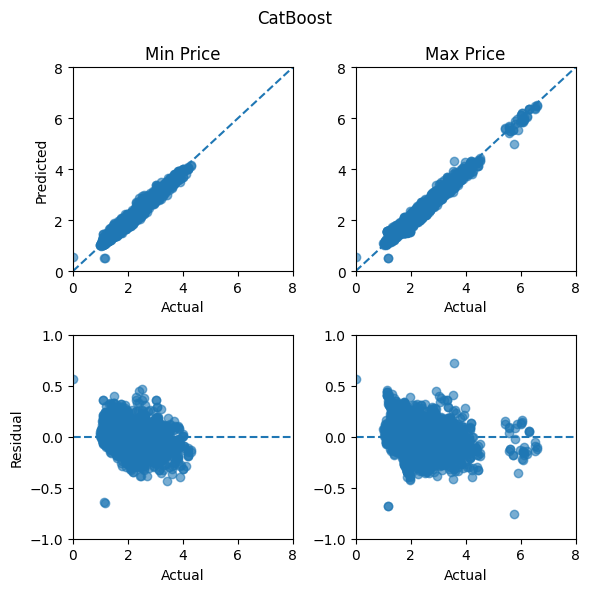

In [11]:
# Evalute the results
y_pred_cat = model_cat.predict(X_test)
print("CatBoost predictions:\n", y_pred_cat)

metrics_cat = evaluate_regression(y_true, y_pred_cat, label="CatBoost")
fig_cat, axs_cat =plot_regression(y_true, y_pred_cat, label="CatBoost")

### Random Forest MultiOutputRegressor
Random Forest cannot handle categorical features directly, so we need to encode it first using OrdinalEncoder.

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor

# Define categorical and numeric features
categorical = ['region', 'group', 'package']
numeric = ['year', 'month', 'day', 'day_of_week']

# Encoding
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), categorical),
        ('num', 'passthrough', numeric)
    ]
)

# Build model
model_rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('rf', MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=800,
            max_depth=None,
            random_state=117
        )
    ))
])

In [13]:
%%time
# Fit the model and time it
start_time = time.perf_counter()

model_rf.fit(X_train, y_train)

end_time = time.perf_counter()
time_rf = end_time - start_time

CPU times: total: 1min 34s
Wall time: 1min 35s


Random Forest predictions:
 [[2.35       2.55      ]
 [1.73320312 2.20155625]
 [2.00904375 2.14423125]
 ...
 [1.5470875  1.84828125]
 [1.48718125 1.85157812]
 [1.91503125 1.99854062]]

--- Random Forest Evaluation ---
MAE :  0.0407
RMSE:  0.0067
R2  :  0.9797




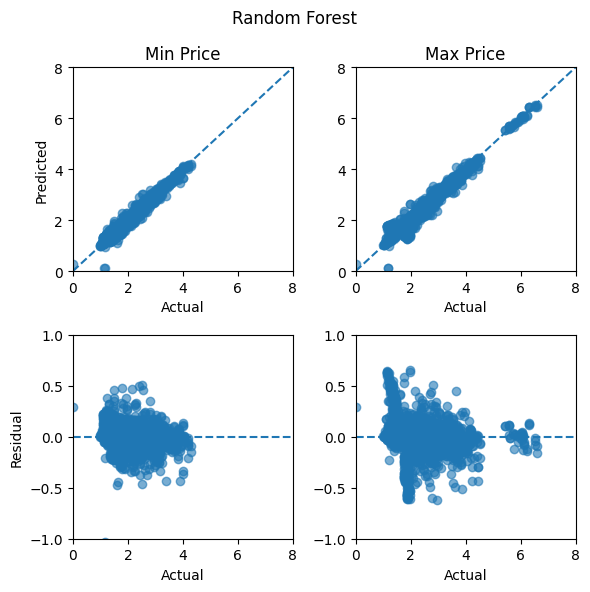

In [14]:
# Evalute the results
y_pred_rf = model_rf.predict(X_test)
label = "Random Forest"
print(f"{label} predictions:\n", y_pred_rf)

metrics_rf = evaluate_regression(y_true, y_pred_rf, label=label)
fig_rf, axs_rf = plot_regression(y_true, y_pred_rf, label=label)

### Neural Network (Keras Multi-output Regression)
Neural networks require encoding and normalization (StandardScaler).

In [15]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Encoding and normalization
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(), categorical),
        ('num', StandardScaler(), numeric) # need to scale the data
    ]
)

X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.fit_transform(X_test)

# Build model
model_keras = Sequential()
model_keras.add(Input(shape=(X_train.shape[1],))) # add input shape as the first layer
model_keras.add(Dense(64, activation='relu')) # add sequential layers
model_keras.add(Dense(64, activation='relu'))
model_keras.add(Dense(2)) # the final layer is the two outputs: price_min, price_max
model_keras.compile(optimizer='adam', loss='mse')

In [16]:
%%time
# Fit the model and time it
start_time = time.perf_counter()

history = model_keras.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

end_time = time.perf_counter()
time_keras = end_time - start_time

CPU times: total: 1min 16s
Wall time: 1min 27s


244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step
Keras Neural Network predictions:
 [[2.5113266 2.6688151]
 [1.86536   2.249851 ]
 [1.8394111 1.9863269]
 ...
 [1.6349467 1.8673811]
 [1.9679555 2.3366215]
 [1.7446884 2.0114331]]

--- Keras Neural Network Evaluation ---
MAE :  0.1703
RMSE:  0.0507
R2  :  0.8329




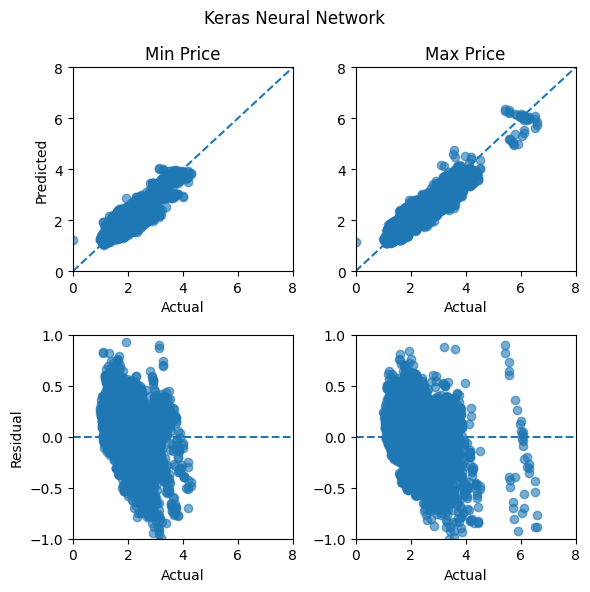

In [17]:
# Evalute the results
y_pred_keras = model_keras.predict(X_test_processed)
label = "Keras Neural Network"
print(f"{label} predictions:\n", y_pred_keras)

metrics_keras = evaluate_regression(y_true, y_pred_keras, label=label)
fig_keras, axs_keras = plot_regression(y_true, y_pred_keras, label=label)

### Final Comparison

The choice of the model depend on both efficiency and accuracy, so let's do a final comparison.

**Note:** feature engineering and hyperparameter tuning are very import steps to optimize ML models, which we didn't have time to go through here, but may improve the performance of models.

In [18]:
comparison_df = pd.DataFrame(columns=('Time', 'MAE', 'RMSE', 'R2'))
comparison_df.loc['Cat'] = [time_cat, *metrics_cat]
comparison_df.loc['RF'] = [time_rf, *metrics_rf]
comparison_df.loc['Keras'] = [time_keras, *metrics_keras]
comparison_df

,Time,MAE,RMSE,R2
Cat,118.641895,0.070522,0.009251,0.970655
RF,95.780342,0.040740,0.006715,0.979735
Keras,87.097968,0.170280,0.050726,0.832930


We can see that the Random Forest model took a relatively short time but performed best. The categorical model, although didn't use the date information and used the longest time, also performed pretty well. The neural network model, while being the fastest, was the least accurate. 

Additionally, looking at the residual plot, it tends to overestimate when the actual price is lower, but overestimate when the price is higher. But similar bias was not observed in the other two models. This could be a combination of the relatively small amount of data and the fact that we didn't tune the hyperparameters.

## Can you build a better model?
<img src='https://i.pinimg.com/564x/4f/f0/92/4ff0922666a17a117220733bbbf0fba1.jpg' alt='You can do better' width=400 />